# Analytic magnetic island and its synthetic soft-X-ray response

This notebook puts a prescribed `m/n` magnetic island on an axisymmetric VAFT equilibrium and computes what the VEST soft-X-ray (SXR) arrays would see as it rotates ([#886](https://github.com/VEST-Tokamak/vaft/issues/886)). It is a forward model only. It does not invert the signals, solve for the island's width, or compute a 3-D equilibrium.

The equilibrium is the **only** source of plasma geometry. No major radius, elongation or Shafranov shift is passed to the island. The resonant surface comes from the equilibrium's `q`, the poloidal angle from its straight-field-line map, and the island's extent from the spacing of its flux surfaces.

Three objects are kept apart throughout, because they are different physics:

| object | what it is | VAFT |
|---|---|---|
| magnetic equilibrium | `psi(R, Z)`, `q(psi_N)` | `solovev_example`, a CHEASE g-file |
| magnetic-island topology | helical flux `Omega(R, Z; t, phi)` | `magnetic_island_topology` |
| SXR emissivity | `epsilon(R, Z; t, phi)` | `island_emissivity` |

The chord signals are line integrals of the emissivity, `B = G epsilon`, where `G` holds exact path lengths (`build_line_integral_operator`).

**Conventions** (see `vaft.process.magnetic_island`):
- `width` is the full island width at the **outboard midplane**. The island is uniform in flux, so it is wider wherever the flux surfaces spread.
- `xi = m theta* - sigma n phi - alpha(t)` uses the PEST angle `theta*` (zero on the outboard midplane, counter-clockwise in R-Z) and the IMAS toroidal angle `phi`. The helicity `sigma` is read from the equilibrium's field direction. The O-point is at `xi = 0` and the X-point at `xi = pi`.

In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from omas import ODS

from vaft.data.eqdsk import read_geqdsk
from vaft.machine_mapping.soft_x_rays import sxr_sightlines
from vaft.machine_mapping.wall import wall
from vaft.process.equilibrium import as_equilibrium, solovev_example, straight_field_line_map
from vaft.process.line_of_sight import build_line_integral_operator, clip_segment_to_polygon, project_emissivity
from vaft.process.magnetic_island import (
    MagneticIslandSpec,
    equilibrium_safety_factor,
    island_emissivity,
    magnetic_island_topology,
    resolve_rational_surface,
)
from vaft.process.soft_x_rays import synthetic_island_soft_x_rays
import pandas as pd

# Jupyter starts in notebooks/; resolve the fixture against the repository root.
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIXTURE = REPO / "test" / "data" / "island_sxr"

## 1. An analytic equilibrium

`solovev_example` builds an exactly known Solov'ev equilibrium with a VEST-like shape: R0 = 0.4 m, aspect ratio 1.7, elongation 1.7, triangularity 0.35 and 100 kA. The toroidal field of 0.13 T places `q = 2` in the core and `q = 3` near the edge. These are the same parameters the CHEASE fixture in section 14 was refined from, and section 14 checks that.

In [ ]:
SOLOVEV = {"topology": "limited", "toroidal_field": 0.13, "a_parameter": 0.5, "resolution": 129}
solovev = solovev_example(**SOLOVEV)
print("parameters:", SOLOVEV)
print(f"magnetic axis ({solovev.magnetic_axis[0]:.4f}, {solovev.magnetic_axis[1]:.4f}) m, "
      f"Ip = {solovev.ip / 1e3:.1f} kA, B0 = {solovev.bt0:.3f} T, COCOS {solovev.convention.cocos}")

parameters: {'topology': 'limited', 'toroidal_field': 0.13, 'a_parameter': 0.5, 'resolution': 129}
magnetic axis (0.4410, 0.0000) m, Ip = 100.0 kA, B0 = 0.130 T, COCOS 11


## 2. Normalized flux and safety factor

`equilibrium_safety_factor` returns the record's own `|q|`. A Solov'ev export carries no `q`, so the profile is computed from the flux map and `F`.

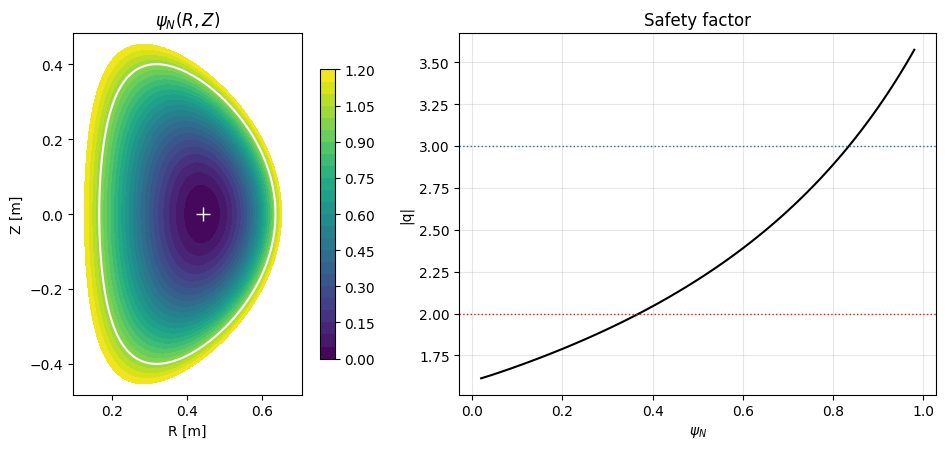

In [ ]:
def psi_norm(eq):
    return (eq.psi - eq.psi_axis) / (eq.psi_boundary - eq.psi_axis)


psi_n_grid, q_profile = equilibrium_safety_factor(solovev)
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4.6), gridspec_kw={"width_ratios": [1, 1.3]})
cs = ax0.contourf(solovev.r, solovev.z, psi_norm(solovev).T, levels=np.linspace(0, 1.2, 25), cmap="viridis")
ax0.plot(solovev.lcfs.r, solovev.lcfs.z, "w-", lw=1.5, label="LCFS")
ax0.plot(*solovev.magnetic_axis, "w+", ms=10)
ax0.set_aspect("equal"); ax0.set_xlabel("R [m]"); ax0.set_ylabel("Z [m]"); ax0.set_title(r"$\psi_N(R,Z)$")
fig.colorbar(cs, ax=ax0, shrink=0.8)
ax1.plot(psi_n_grid, q_profile, "k-")
for m, color in ((2, "C3"), (3, "C0")):
    ax1.axhline(m, color=color, ls=":", lw=1)
ax1.set_xlabel(r"$\psi_N$"); ax1.set_ylabel("|q|"); ax1.set_title("Safety factor"); ax1.grid(alpha=0.3)
fig.tight_layout()

## 3. The resonant surface from `q = m/n`

The surface is located where the equilibrium's own `q` equals `m/n`, refined by a root solve. The island spec never takes a radius. A mode the profile does not contain fails explicitly.

In [ ]:
for m in (2, 3):
    psi_s, q_s = resolve_rational_surface(solovev, m, 1)
    print(f"q = {m}/1: psi_N,s = {psi_s:.5f}, q there = {q_s:.8f}")
try:
    resolve_rational_surface(solovev, 1, 1)
except ValueError as error:
    print("q = 1/1:", error)

q = 2/1: psi_N,s = 0.36999, q there = 2.00000000
q = 3/1: psi_N,s = 0.83527, q there = 3.00000000
q = 1/1: q = 1/1 = 1 does not occur in this equilibrium: |q| spans [1.613, 3.574] over psi_N in [0.02, 0.98]


## 4. The straight-field-line angle and the helical phase

`theta*` is the PEST angle, in which field lines are straight: along a flux surface `d theta* ∝ dl / (R |grad psi|)`. It equals the geometric angle only on a circular, concentric equilibrium. Here it advances slowly on the outboard side and quickly on the inboard side: a field line covers the outboard side in fewer toroidal turns, so equal steps of `theta*` span a longer arc there. Its contours are therefore sparse outboard and crowded inboard.

helicity sigma = -1 (Ip and B_phi both along +phi: sigma = -1)


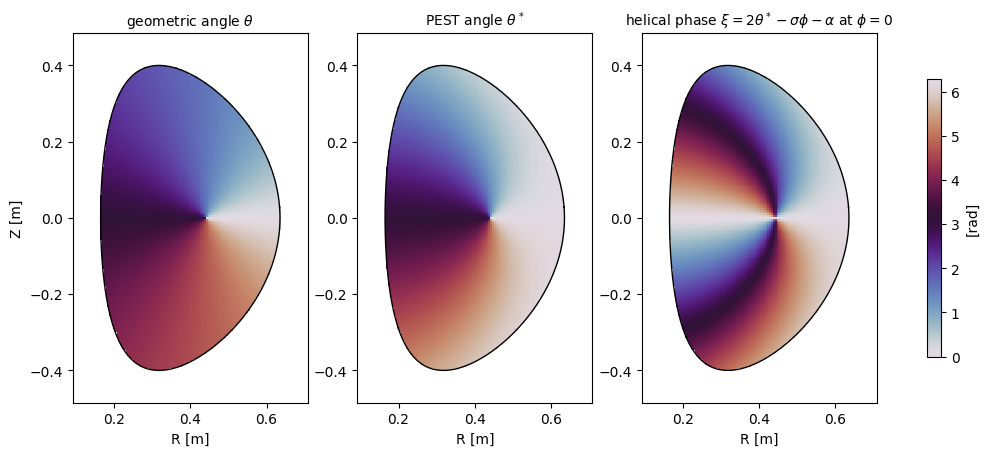

In [ ]:
sfl = straight_field_line_map(solovev.psi, solovev.r, solovev.z, solovev.psi_axis,
                              solovev.psi_boundary, solovev.magnetic_axis)
rr, zz = np.meshgrid(solovev.r, solovev.z, indexing="ij")
theta_star = sfl.theta_star(rr, zz)
geometric = np.where(np.isfinite(theta_star), sfl.geometric_angle(rr, zz), np.nan)

island = MagneticIslandSpec(m=2, n=1, width=0.03)
topology = magnetic_island_topology(solovev, island, sfl_map=sfl)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.8))
for ax, field, title in zip(axes, (geometric, theta_star, topology.helical_phase),
                            (r"geometric angle $\theta$", r"PEST angle $\theta^*$",
                             r"helical phase $\xi = 2\theta^* - \sigma\phi - \alpha$ at $\phi=0$")):
    pc = ax.pcolormesh(solovev.r, solovev.z, field.T, cmap="twilight", vmin=0, vmax=2 * np.pi, shading="auto")
    ax.plot(solovev.lcfs.r, solovev.lcfs.z, "k-", lw=1)
    ax.set_aspect("equal"); ax.set_xlabel("R [m]"); ax.set_title(title, fontsize=10)
axes[0].set_ylabel("Z [m]")
fig.colorbar(pc, ax=axes, shrink=0.75, label="[rad]")
print(f"helicity sigma = {topology.helicity:+d} (Ip and B_phi both along +phi: sigma = -1)")

## 5–7. A static island: O-point, X-point, separatrix and width

`Omega = 8 (x/W)^2 - cos xi` is `-1` at the O-point and `+1` on the separatrix. `x` is the outboard-midplane distance between the flux surface through a point and the resonant surface. On the outboard midplane it is the exact radial distance, so the separatrix branches through an outboard O-point are `W` apart there by construction. The check below does not reuse that construction. It reads the separatrix crossings off the gridded helical flux `topology.helical_flux` on the midplane row, so it includes the discretization, and it repeats the measurement on a finer grid.

prescribed full width W = 30.00 mm
measured from the gridded helical flux: 29.65 mm on 129 points, 29.94 mm on 257 points
in normalized flux the island spans 0.1940 around psi_N,s = 0.3700


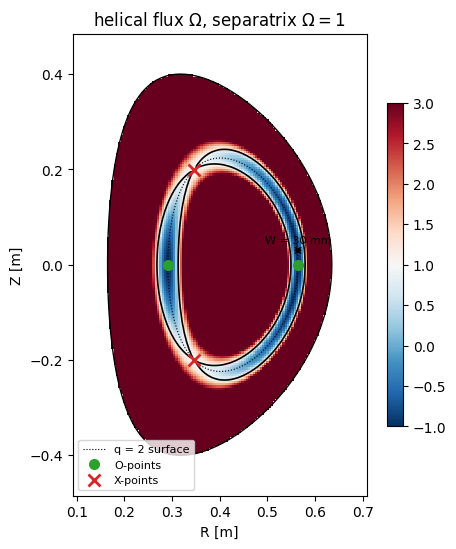

In [ ]:
fig, ax = plt.subplots(figsize=(5.2, 6))
omega = topology.helical_flux
pc = ax.pcolormesh(solovev.r, solovev.z, np.clip(omega, -1, 3).T, cmap="RdBu_r", vmin=-1, vmax=3, shading="auto")
ax.contour(solovev.r, solovev.z, omega.T, levels=[1.0], colors="k", linewidths=1.2)
ax.plot(*topology.rational_surface[1:], "k:", lw=0.8, label="q = 2 surface")
ax.plot(*topology.o_points.T, "o", color="C2", ms=7, label="O-points")
ax.plot(*topology.x_points.T, "x", color="C3", ms=8, mew=2, label="X-points")
ax.plot(solovev.lcfs.r, solovev.lcfs.z, "k-", lw=1)
ax.set_aspect("equal"); ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]")
ax.set_title(r"helical flux $\Omega$, separatrix $\Omega = 1$"); ax.legend(loc="lower left", fontsize=8)
fig.colorbar(pc, ax=ax, shrink=0.7)

def grid_width(top, eq):
    # Full width between the Omega = 1 crossings on the grid row through the axis.
    row = int(np.argmin(np.abs(eq.z - top.sfl_map.magnetic_axis[1])))
    o_r = top.o_points[:, 0].max()
    near = np.isfinite(top.helical_flux[:, row]) & (np.abs(eq.r - o_r) < 2 * top.spec.width)
    r, excess = eq.r[near], top.helical_flux[near, row] - 1.0
    crossings = [r[i] - excess[i] * (r[i + 1] - r[i]) / (excess[i + 1] - excess[i])
                 for i in range(r.size - 1) if excess[i] * excess[i + 1] < 0]
    return crossings[-1] - crossings[0], crossings


measured, crossings = grid_width(topology, solovev)
ax.annotate("", xy=(crossings[0], 0.03), xytext=(crossings[-1], 0.03),
            arrowprops={"arrowstyle": "<->", "color": "k", "lw": 1})
ax.text(np.mean(crossings), 0.045, f"W = {island.width * 1e3:.0f} mm", ha="center", fontsize=8)
fine_eq = solovev_example(**{**SOLOVEV, "resolution": 257})
fine_width, _ = grid_width(magnetic_island_topology(fine_eq, island), fine_eq)
print(f"prescribed full width W = {island.width * 1e3:.2f} mm")
print(f"measured from the gridded helical flux: {measured * 1e3:.2f} mm on {solovev.r.size} points, "
      f"{fine_width * 1e3:.2f} mm on {fine_eq.r.size} points")
print(f"in normalized flux the island spans {topology.width_psi_n:.4f} around psi_N,s = {topology.psi_n_s:.4f}")

Changing the phase `alpha` moves the island rigidly without resizing it. One full turn of `alpha` returns the same topology.

one full turn restores the helical flux: True


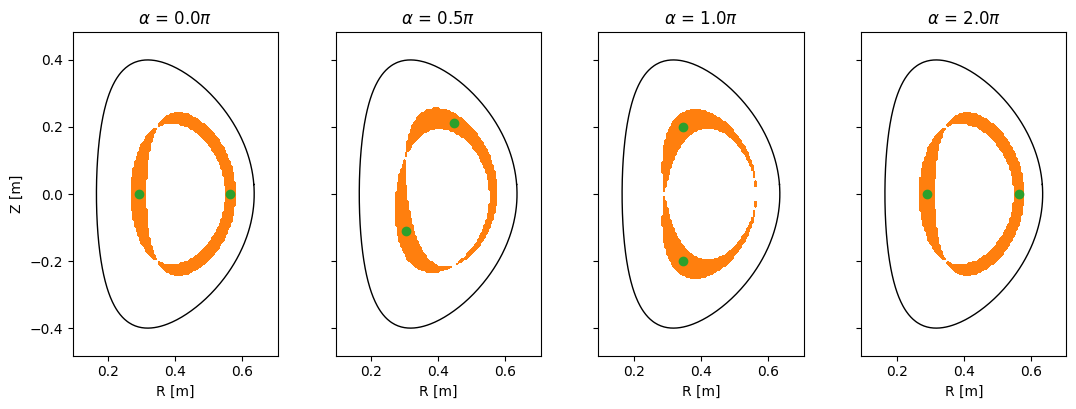

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4.2), sharey=True)
for ax, alpha in zip(axes, (0.0, np.pi / 2, np.pi, 2 * np.pi)):
    turned = magnetic_island_topology(solovev, MagneticIslandSpec(2, 1, 0.03, phase=alpha), sfl_map=sfl)
    ax.contourf(solovev.r, solovev.z, turned.inside_separatrix.T.astype(float), levels=[0.5, 1.5], colors=["C1"])
    ax.plot(*turned.o_points.T, "o", color="C2")
    ax.plot(solovev.lcfs.r, solovev.lcfs.z, "k-", lw=1)
    ax.set_aspect("equal"); ax.set_title(rf"$\alpha$ = {alpha / np.pi:.1f}$\pi$"); ax.set_xlabel("R [m]")
axes[0].set_ylabel("Z [m]")
full_turn = magnetic_island_topology(solovev, MagneticIslandSpec(2, 1, 0.03, phase=2 * np.pi), sfl_map=sfl)
print("one full turn restores the helical flux:",
      np.allclose(full_turn.helical_flux, topology.helical_flux, equal_nan=True))

## 8–9. Emissivity: background, island-only and flattening

Magnetic topology and emissivity are different things. The background `epsilon_0(psi_N)` below is a simple peaked profile, not an atomic-physics calculation.
- The **island-only** model adds `A M(Omega)`. `M` is a smooth mask that is 1 inside the separatrix.
- The **flattening** model pulls the emissivity inside the island toward its value on the resonant surface: `epsilon = epsilon_0 + A M (epsilon_0(psi_N,s) - epsilon_0)`. With `A = 1` the island is flat, so the emissivity drops on its inner side and rises on its outer side.

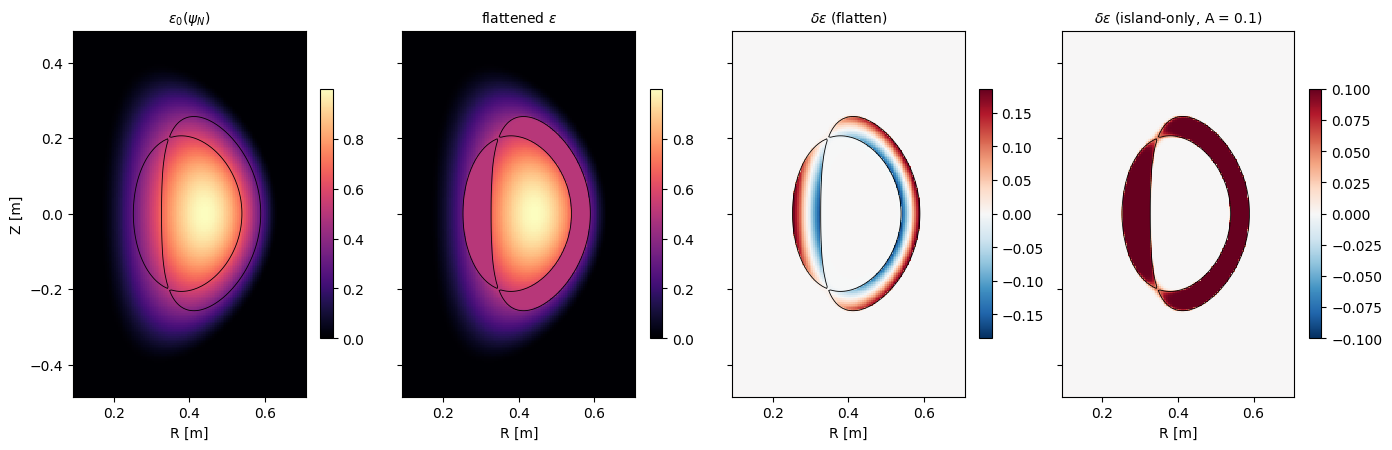

In [ ]:
def background(psi_n):
    return (1.0 - psi_n) ** 1.5  # arbitrary units


wide = magnetic_island_topology(solovev, MagneticIslandSpec(2, 1, 0.05), sfl_map=sfl)
eps0, _ = island_emissivity(wide, profile=background, amplitude=0.0)
eps_island, d_island = island_emissivity(wide, profile=background, model="island", amplitude=0.1)
eps_flat, d_flat = island_emissivity(wide, profile=background, model="flatten", amplitude=1.0)

fig, axes = plt.subplots(1, 4, figsize=(14, 4.6), sharey=True)
panels = ((eps0, r"$\epsilon_0(\psi_N)$", "magma", None), (eps_flat, r"flattened $\epsilon$", "magma", None),
          (d_flat, r"$\delta\epsilon$ (flatten)", "RdBu_r", np.abs(d_flat).max()),
          (d_island, r"$\delta\epsilon$ (island-only, A = 0.1)", "RdBu_r", np.abs(d_island).max()))
for ax, (field, title, cmap, sym) in zip(axes, panels):
    kwargs = {"vmin": -sym, "vmax": sym} if sym else {}
    pc = ax.pcolormesh(solovev.r, solovev.z, field.T, cmap=cmap, shading="auto", **kwargs)
    ax.contour(solovev.r, solovev.z, wide.helical_flux.T, levels=[1.0], colors="k", linewidths=0.6)
    ax.set_aspect("equal"); ax.set_title(title, fontsize=10); ax.set_xlabel("R [m]")
    fig.colorbar(pc, ax=ax, shrink=0.6)
axes[0].set_ylabel("Z [m]")
fig.tight_layout()

## 10–12. VEST SXR geometry and the line-integral operator

The chords come from the machine mapping, as 72 chords in four arrays. The 17592 arrays (horizontal and vertical) are at `phi = 0` and the 22577 arrays (lower-mid and bottom) at `phi = 240 deg`. The 22577 angle is still provisional ([#746](https://github.com/VEST-Tokamak/vaft/issues/746)). Each chord is clipped to the limiter.

`G[i, j]` is the exact length of chord `i` inside cell `j`, so a uniform field integrates to each chord's length inside the limiter and the grid. There is no mask resampling anywhere.

72 chords in arrays ['horizontal', 'vertical', 'lowermid', 'bottom']; toroidal angles [0.0, 240.0] deg
operator at phi = 0: 40 chords x 26445 cells, 7761 non-zero path lengths


Text(0.5, 1.0, 'SXR chords clipped to the limiter')

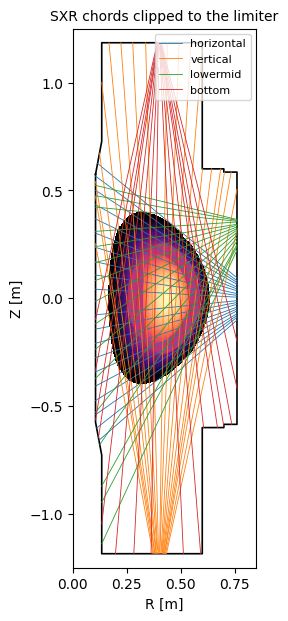

In [ ]:
chords = sxr_sightlines()
ods = ODS()
wall(ods)
limiter = (np.asarray(ods["wall.description_2d.0.limiter.unit.0.outline.r"]),
           np.asarray(ods["wall.description_2d.0.limiter.unit.0.outline.z"]))
arrays = np.array([str(label.split(":")[0]) for label in chords.labels])
names = [str(name) for name in dict.fromkeys(arrays)]

G0 = build_line_integral_operator(solovev.r, solovev.z, chords.subset(np.isclose(chords.phi, 0.0)), domain=limiter)
print(f"{len(chords)} chords in arrays {names}; toroidal angles "
      f"{sorted({round(float(np.degrees(p)), 1) for p in chords.phi})} deg")
print(f"operator at phi = 0: {G0.shape[0]} chords x {G0.shape[1]} cells, {G0.nnz} non-zero path lengths")

fig, ax = plt.subplots(figsize=(5.5, 7))
ax.pcolormesh(solovev.r, solovev.z, np.ma.masked_equal(eps_flat, 0.0).T, cmap="magma", shading="auto")
ax.plot(*limiter, "k-", lw=1.2)
for name, color in zip(names, ("C0", "C1", "C2", "C3")):
    for k, i in enumerate(np.flatnonzero(arrays == name)):
        start = np.array([chords.r1[i], chords.z1[i]])
        step = np.array([chords.r2[i], chords.z2[i]]) - start
        for lo, hi in clip_segment_to_polygon(start, start + step, *limiter):  # the part the operator counts
            ax.plot(*np.column_stack([start + lo * step, start + hi * step]), color=color, lw=0.6,
                    label=name if k == 0 else None)
ax.set_xlim(0.0, 0.85); ax.set_ylim(-1.25, 1.25); ax.set_aspect("equal")
ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]"); ax.legend(fontsize=8, loc="upper right")
ax.set_title("SXR chords clipped to the limiter", fontsize=10)

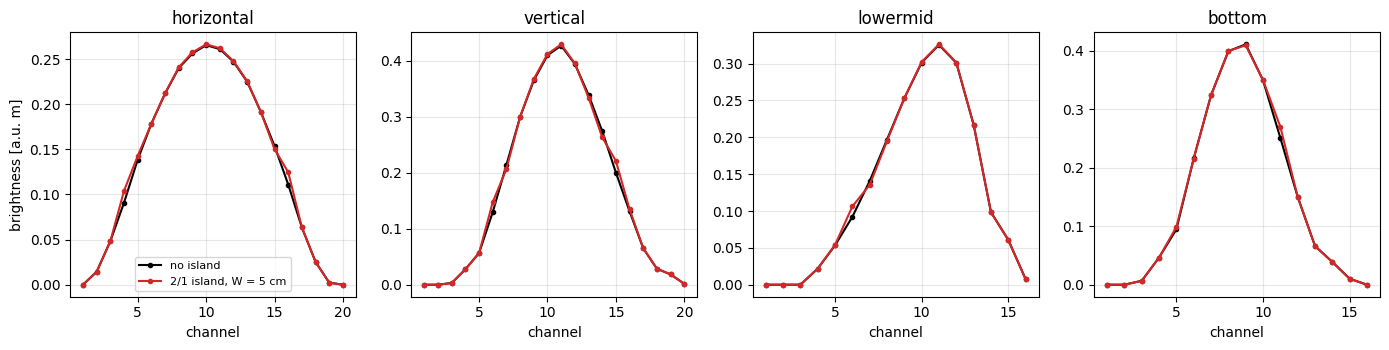

In [ ]:
static = synthetic_island_soft_x_rays(solovev, MagneticIslandSpec(2, 1, 0.05), chords,
                                      emissivity_profile=background, domain=limiter)
axisymmetric = synthetic_island_soft_x_rays(solovev, MagneticIslandSpec(2, 1, 0.05), chords,
                                            emissivity_profile=background, domain=limiter, amplitude=0.0)
fig, axes = plt.subplots(1, len(names), figsize=(14, 3.6))
for ax, name in zip(axes, names):
    pick = arrays == name
    channel = np.arange(1, pick.sum() + 1)
    ax.plot(channel, axisymmetric.brightness[0, pick], "k.-", label="no island")
    ax.plot(channel, static.brightness[0, pick], "C3.-", label="2/1 island, W = 5 cm")
    ax.set_title(name); ax.set_xlabel("channel"); ax.grid(alpha=0.3)
axes[0].set_ylabel("brightness [a.u. m]"); axes[0].legend(fontsize=8)
fig.tight_layout()

## 13. A rigidly rotating island

A rotating island is simulated by advancing the helical phase `alpha(t) = omega t`. The topology is re-evaluated at each time, not produced by shifting a precomputed image. Each array sees the island in its own toroidal plane. From `xi = m theta* - sigma n phi - omega t`, the emissivity in the plane at `phi` is the `phi = 0` pattern shifted in time: `epsilon(t, phi) = epsilon(t + sigma n phi / omega, 0)`. The 240 deg plane therefore lags by `-sigma n Delta phi / omega`, which is 133 us here with `sigma = -1`. The two arrays at 240 deg are different chords from the two at 0 deg, so their signals are not simply time-shifted copies; the check below compares the emissivity fields themselves. The sign of `omega` sets the poloidal direction, and the toroidal propagation direction follows from the helicity.

dominant chord-signal frequency: 5.00 kHz (rotation 5.0 kHz); its second harmonic carries 21% of it
240 deg plane lags the 0 deg plane by 133.3 us: max |difference| of the shifted fields 1.4e-15 (field max 1.00)


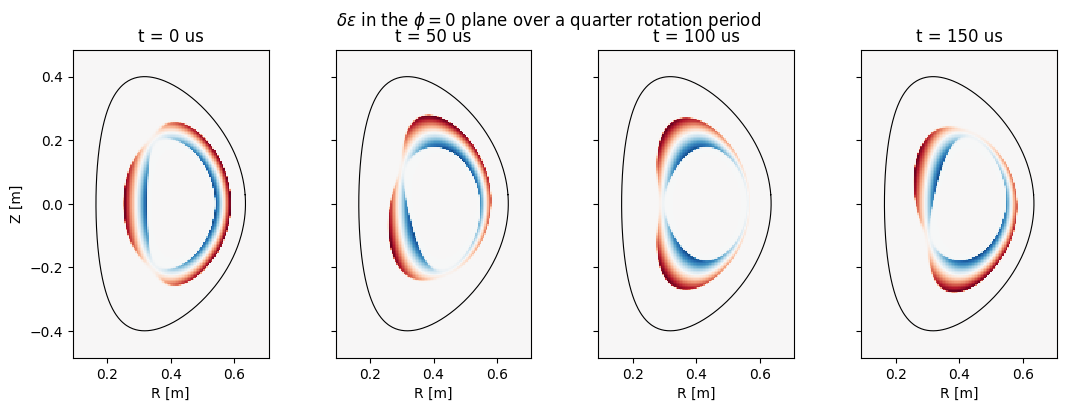

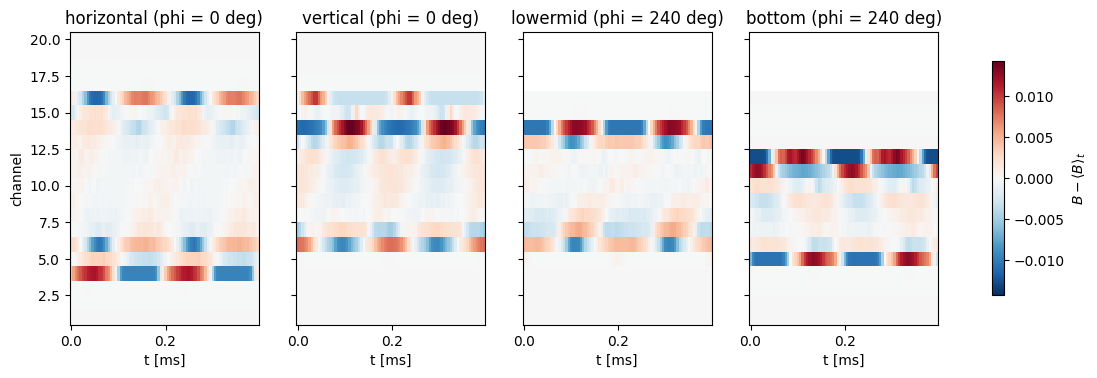

In [ ]:
f_rot = 5e3
spec = MagneticIslandSpec(2, 1, 0.05, angular_frequency=2 * np.pi * f_rot)
times = np.arange(80) * (2.0 / f_rot) / 80  # two periods, no duplicated endpoint
rotating = synthetic_island_soft_x_rays(solovev, spec, chords, time=times,
                                        emissivity_profile=background, domain=limiter, keep_fields=True)
fluct = rotating.brightness - rotating.brightness.mean(axis=0)

fig, axes = plt.subplots(1, 4, figsize=(13, 4), sharey=True)
for ax, k in zip(axes, (0, 10, 20, 30)):
    ax.pcolormesh(solovev.r, solovev.z, rotating.delta_emissivity[k, 0].T, cmap="RdBu_r",
                  vmin=-np.abs(rotating.delta_emissivity).max(), vmax=np.abs(rotating.delta_emissivity).max(),
                  shading="auto")
    ax.plot(solovev.lcfs.r, solovev.lcfs.z, "k-", lw=0.8)
    ax.set_aspect("equal"); ax.set_title(f"t = {times[k] * 1e6:.0f} us"); ax.set_xlabel("R [m]")
axes[0].set_ylabel("Z [m]")
fig.suptitle(r"$\delta\epsilon$ in the $\phi = 0$ plane over a quarter rotation period")

fig, axes = plt.subplots(1, len(names), figsize=(14, 3.8), sharey=True)
for ax, name in zip(axes, names):
    pick = arrays == name
    pc = ax.pcolormesh(times * 1e3, np.arange(1, pick.sum() + 1), fluct[:, pick].T, cmap="RdBu_r",
                       vmin=-np.abs(fluct).max(), vmax=np.abs(fluct).max(), shading="auto")
    ax.set_title(f"{name} (phi = {np.degrees(chords.phi[pick][0]):.0f} deg)"); ax.set_xlabel("t [ms]")
axes[0].set_ylabel("channel")
fig.colorbar(pc, ax=axes, shrink=0.8, label=r"$B - \langle B\rangle_t$")
spectrum = np.abs(np.fft.rfft(fluct, axis=0)).sum(axis=1)
freqs = np.fft.rfftfreq(times.size, d=times[1] - times[0])
print(f"dominant chord-signal frequency: {freqs[np.argmax(spectrum[1:]) + 1] / 1e3:.2f} kHz "
      f"(rotation {f_rot / 1e3:.1f} kHz); its second harmonic carries "
      f"{spectrum[np.argmin(np.abs(freqs - 2 * f_rot))] / spectrum[np.argmin(np.abs(freqs - f_rot))]:.0%} of it")

delta_phi = np.deg2rad(240.0)
lag = -rotating.topology.helicity * spec.n * delta_phi / spec.angular_frequency
t0 = times[7]
at_240 = rotating.topology.rephase(time=t0, phi=delta_phi)
at_0 = rotating.topology.rephase(time=t0 - lag, phi=0.0)
e240, _ = island_emissivity(at_240, profile=background)
e0, _ = island_emissivity(at_0, profile=background)
print(f"240 deg plane lags the 0 deg plane by {lag * 1e6:.1f} us: max |difference| of the shifted fields "
      f"{np.max(np.abs(e240 - e0)):.1e} (field max {np.max(e240):.2f})")

## 14. The CHEASE-refined equilibrium

CHEASE re-solves the same problem as a fixed-boundary equilibrium on its own mesh, using the Solov'ev boundary, `p'` and `FF'`. By default it rescales the current to hold `q95`, so its `q` profile, and with it every resonant surface, moves a little. Running CHEASE needs the external binary, so its output is kept as a fixture together with its provenance. To regenerate it:

```bash
PYTHONPATH=$PWD CHEASE=/path/to/chease python workflow/island_sxr/generate_chease_fixture.py
```

In [ ]:
provenance = json.loads((FIXTURE / "solovev_vest_chease.json").read_text())
assert provenance["solovev_example"] == SOLOVEV, "the fixture was refined from other parameters"
refined = as_equilibrium(read_geqdsk(str(FIXTURE / "solovev_vest_chease.geqdsk")))
for key in ("generator", "solovev_example", "chease_config", "chease_source_revision", "vaft_commit", "generated"):
    print(f"{key:24s} {provenance[key]}")
print(f"refined record: COCOS {refined.convention.cocos}, grid {refined.psi.shape}, "
      f"Ip = {refined.ip / 1e3:.1f} kA, axis ({refined.magnetic_axis[0]:.4f}, {refined.magnetic_axis[1]:.4f}) m")

generator                workflow/island_sxr/generate_chease_fixture.py
solovev_example          {'topology': 'limited', 'toroidal_field': 0.13, 'a_parameter': 0.5, 'resolution': 129}
chease_config            {'nw': 129, 'create_plot': False}
chease_source_revision   0b2a7d2
vaft_commit              v0.7.1-184-g68c151291d-dirty
generated                2026-09-21T09:58:53+00:00
refined record: COCOS 1, grid (129, 129), Ip = 98.1 kA, axis (0.4410, 0.0000) m


## 15–16. The same island on both equilibria

Both equilibria get the identical `MagneticIslandSpec`: the same `m/n`, the same outboard-midplane width and the same phase convention. The resonant surface, the flux-space width and the helicity are recomputed from each equilibrium. The CHEASE g-file stores flux per radian and declares COCOS 1, the per-radian twin of the Solov'ev record's COCOS 11: same orientation, so the plasma current, the field and the helicity point the same way in both. Differences in topology or signal come from the equilibria, not from the phantom. Part of the signal difference is discretization, because each equilibrium lives on its own grid, so it is measured below against the same Solov'ev on a finer grid.

          psi_N(q=2)  psi_N(q=3)  W in psi_N  outboard O-point R [m]  helicity  COCOS
Solov'ev     0.36999     0.83527     0.32391                 0.56438        -1     11
CHEASE       0.36155     0.83351     0.32070                 0.56266        -1      1


Text(0.5, 1.0, "2/1 separatrix and LCFS: Solov'ev vs CHEASE")

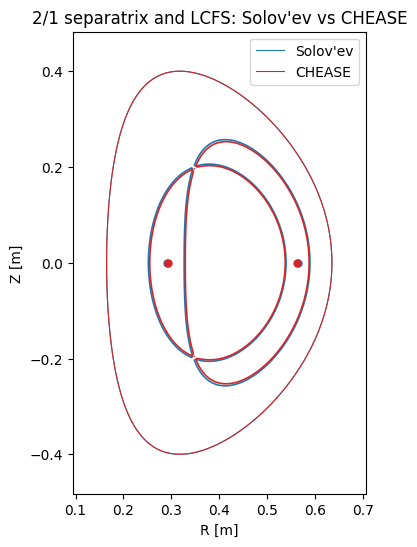

In [ ]:
spec = MagneticIslandSpec(2, 1, 0.05)
cases = {"Solov'ev": solovev, "CHEASE": refined}
tops = {name: magnetic_island_topology(eq, spec) for name, eq in cases.items()}
rows = {}
for name, top in tops.items():
    psi3, _ = resolve_rational_surface(cases[name], 3, 1)
    rows[name] = {"psi_N(q=2)": top.psi_n_s, "psi_N(q=3)": psi3, "W in psi_N": top.width_psi_n,
                  "outboard O-point R [m]": top.o_points[:, 0].max(), "helicity": top.helicity,
                  "COCOS": cases[name].convention.cocos}

table = pd.DataFrame(rows).T
for column in ("helicity", "COCOS"):
    table[column] = table[column].astype(int)
print(table.to_string(float_format=lambda v: f"{v:.5f}"))

fig, ax = plt.subplots(figsize=(5.2, 6))
for (name, top), color in zip(tops.items(), ("C0", "C3")):
    eq = cases[name]
    ax.contour(eq.r, eq.z, top.helical_flux.T, levels=[1.0], colors=color, linewidths=1.2)
    ax.plot(eq.lcfs.r, eq.lcfs.z, "-", color=color, lw=0.8, label=name)
    ax.plot(*top.o_points.T, "o", color=color, ms=5)
ax.set_aspect("equal"); ax.set_xlabel("R [m]"); ax.set_ylabel("Z [m]"); ax.legend()
ax.set_title("2/1 separatrix and LCFS: Solov'ev vs CHEASE")

largest |CHEASE - Solov'ev| = 1.48% of the maximum; the same Solov'ev on 257 vs 129 points differs by 0.43%


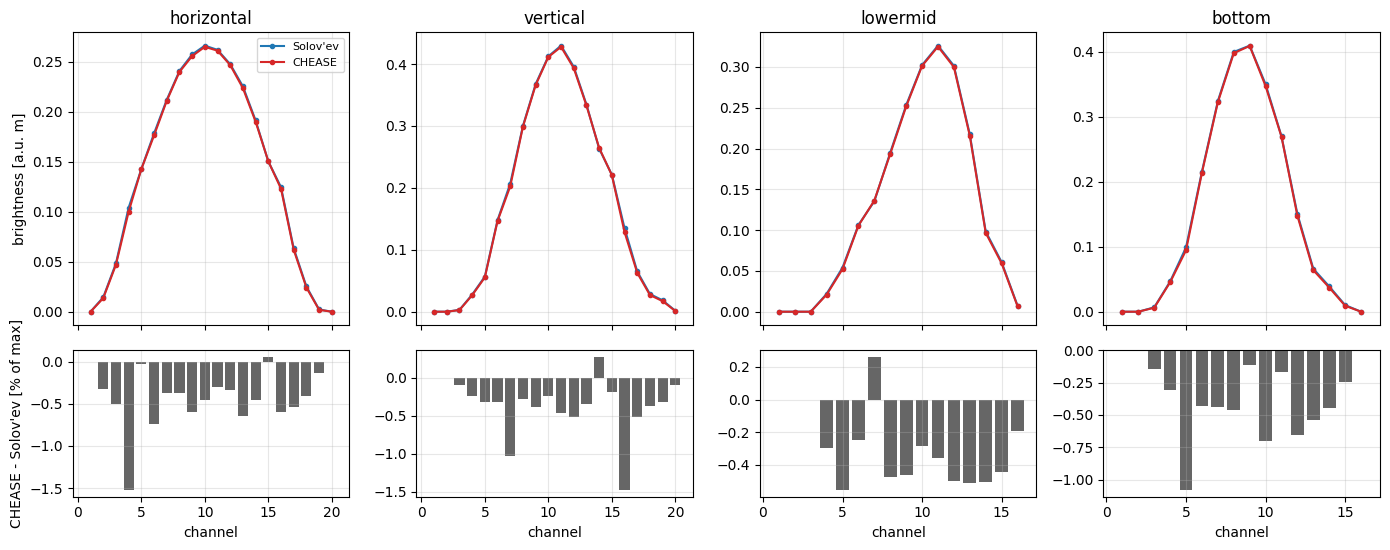

In [ ]:
responses = {name: synthetic_island_soft_x_rays(eq, spec, chords, emissivity_profile=background,
                                                domain=limiter, keep_fields=False).brightness[0]
             for name, eq in cases.items()}
fig, axes = plt.subplots(2, len(names), figsize=(14, 5.6), sharex="col",
                         gridspec_kw={"height_ratios": [2, 1]})
for col, name in enumerate(names):
    pick = arrays == name
    channel = np.arange(1, pick.sum() + 1)
    for label, color in (("Solov'ev", "C0"), ("CHEASE", "C3")):
        axes[0, col].plot(channel, responses[label][pick], ".-", color=color, label=label)
    rel = (responses["CHEASE"][pick] - responses["Solov'ev"][pick]) / np.abs(responses["Solov'ev"][pick]).max()
    axes[1, col].bar(channel, 100 * rel, color="0.4")
    axes[0, col].set_title(name); axes[1, col].set_xlabel("channel")
    for ax in axes[:, col]:
        ax.grid(alpha=0.3)
axes[0, 0].set_ylabel("brightness [a.u. m]"); axes[1, 0].set_ylabel("CHEASE - Solov'ev [% of max]")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()

fine = synthetic_island_soft_x_rays(fine_eq, spec, chords, emissivity_profile=background, domain=limiter,
                                    keep_fields=False).brightness[0]
analytic_signal, refined_signal = responses["Solov'ev"], responses["CHEASE"]
scale = np.abs(analytic_signal).max()
between = np.abs(refined_signal - analytic_signal).max() / scale
discretization = np.abs(fine - analytic_signal).max() / scale
print(f"largest |CHEASE - Solov'ev| = {between:.2%} of the maximum; "
      f"the same Solov'ev on 257 vs 129 points differs by {discretization:.2%}")

## Summary

- **Equilibrium only.** The island is placed on the equilibrium alone. The same spec on the analytic and the CHEASE-refined equilibria gives resonant surfaces, flux widths and chord signals that differ only through the equilibria themselves.
- **Width check.** The prescribed full width is recovered exactly on the outboard midplane. Elsewhere the island follows the flux expansion.
- **Signals.** The chord signals are exact path-length integrals of the emissivity, and a rotating island shows up in each toroidal plane with the phase its helicity dictates.

Out of scope here, per #886: tomographic inversion (#267), island-width evolution, and detector or filter response.